In [1]:
%reload_ext autoreload
%autoreload 2
import sys, os
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Add project root to path
project_root = '/sdf/group/neutrino/pgranger/larnd-sim-jax/src'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

%cd /sdf/group/neutrino/pgranger/larnd-sim-jax

from larndsim.consts_jax import build_params_class, load_detector_properties, load_lut
from optimize.strategies import LUTSimulation
from optimize.dataio import TracksDataset, DataLoader
from optimize.ranges import ranges

print("Setup complete.")

/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/sdf/group/neutrino/pgranger/larnd-sim-jax
Setup complete.


In [3]:
# --- Configuration ---
INPUT_FILE = '/sdf/data/neutrino/cyifan/diffsim_input/true_through_muon_edep_10cm_vol1cm.h5'
LUT_FILE = 'src/larndsim/detector_properties/response_44_v2a_full_tick.npz'
DET_PROPS = 'src/larndsim/detector_properties/module0.yaml'
PIXEL_LAYOUTS = 'src/larndsim/pixel_layouts/multi_tile_layout-2.4.16_v4.yaml'

RELEVANT_PARAMS = ['Ab', 'kb', 'lifetime', 'tran_diff', 'long_diff', 'eField', 'shift_x', 'shift_y', 'shift_z']
ELECTRON_SAMPLING_RESOLUTION = 0.1
NUMBER_PIX_NEIGHBORS = 4
SIGNAL_LENGTH = 150

# Set true lifetime to 2200 us to test the fit
TRUE_LIFETIME = 2200.0

ParamsClass = build_params_class(RELEVANT_PARAMS)
ref_params = load_detector_properties(ParamsClass, DET_PROPS, PIXEL_LAYOUTS)
nom_vals = {p: float(ranges[p]['nom']) for p in RELEVANT_PARAMS}
ref_params = ref_params.replace(**nom_vals)
ref_params = ref_params.replace(
    electron_sampling_resolution=ELECTRON_SAMPLING_RESOLUTION,
    number_pix_neighbors=NUMBER_PIX_NEIGHBORS,
    signal_length=SIGNAL_LENGTH,
    time_window=SIGNAL_LENGTH,
    lifetime=TRUE_LIFETIME
)

response, ref_params = load_lut(LUT_FILE, ref_params)
sim_stochastic = LUTSimulation(response)
print("Configuration complete. True Lifetime = ", TRUE_LIFETIME)

INFO:larndsim.consts_jax:Loading response from npz file
Could not load symbol cuFuncGetName. Error: /.singularity.d/libs/libcuda.so.1: undefined symbol: cuFuncGetName


Configuration complete. True Lifetime =  2200.0


In [5]:
# --- Generate Data ---
dataset = TracksDataset(filename=INPUT_FILE, nevents=-1, max_nbatch=20, max_batch_len=1000,
                        electron_sampling_resolution=ELECTRON_SAMPLING_RESOLUTION)
dataloader = DataLoader(dataset, batch_size=1)

track_fields = dataset.get_track_fields()
# Combine a few batches to get good statistics
tracks_list = [dataloader[i].reshape(-1, len(track_fields)) for i in range(2)]
tracks_raw = jnp.concatenate(tracks_list, axis=0)
print(f"Loaded {tracks_raw.shape[0]} segments.")

target_prediction = sim_stochastic.predict(ref_params, tracks_raw, track_fields, rngkey=42)

adcs = np.array(target_prediction['adcs'])
ticks = np.array(target_prediction['ticks'])
print(f"Simulated {len(adcs)} hits.")

INFO:optimize.dataio:-- The used simulation data includes a total track length of 19845.72203063965 cm.
INFO:optimize.dataio:-- The number of simulation batches is 20.


Loaded 24788 segments.
Simulated 8021 hits.


In [6]:
# --- Profile and Fit ---
# Bin the data by ticks
min_tick = int(np.min(ticks))
max_tick = int(np.max(ticks))
num_bins = 50
tick_bins = np.linspace(min_tick, max_tick, num_bins + 1)
tick_centers = 0.5 * (tick_bins[1:] + tick_bins[:-1])

# Calculate median ADC in each bin to avoid Landau tail bias
median_adcs = []
valid_centers = []
for i in range(num_bins):
    mask = (ticks >= tick_bins[i]) & (ticks < tick_bins[i+1])
    if np.sum(mask) > 10:  # Require at least 10 hits for a robust median
        median_adcs.append(np.median(adcs[mask]))
        valid_centers.append(tick_centers[i])

median_adcs = np.array(median_adcs)
valid_centers = np.array(valid_centers)

# Define exponential decay function
t_sampling = ref_params.t_sampling  # microseconds per tick

def exp_decay(t, q0, tau_us):
    return q0 * np.exp(- (t * t_sampling) / tau_us)

# Initial guess
p0 = [np.max(median_adcs), 2000.0]
popt, pcov = curve_fit(exp_decay, valid_centers, median_adcs, p0=p0)

fitted_q0, fitted_tau = popt
tau_err = np.sqrt(np.diag(pcov))[1]

print(f"True Lifetime: {TRUE_LIFETIME:.2f} us")
print(f"Fitted Lifetime: {fitted_tau:.2f} +/- {tau_err:.2f} us")

True Lifetime: 2200.00 us
Fitted Lifetime: 11019.19 +/- 4916.43 us


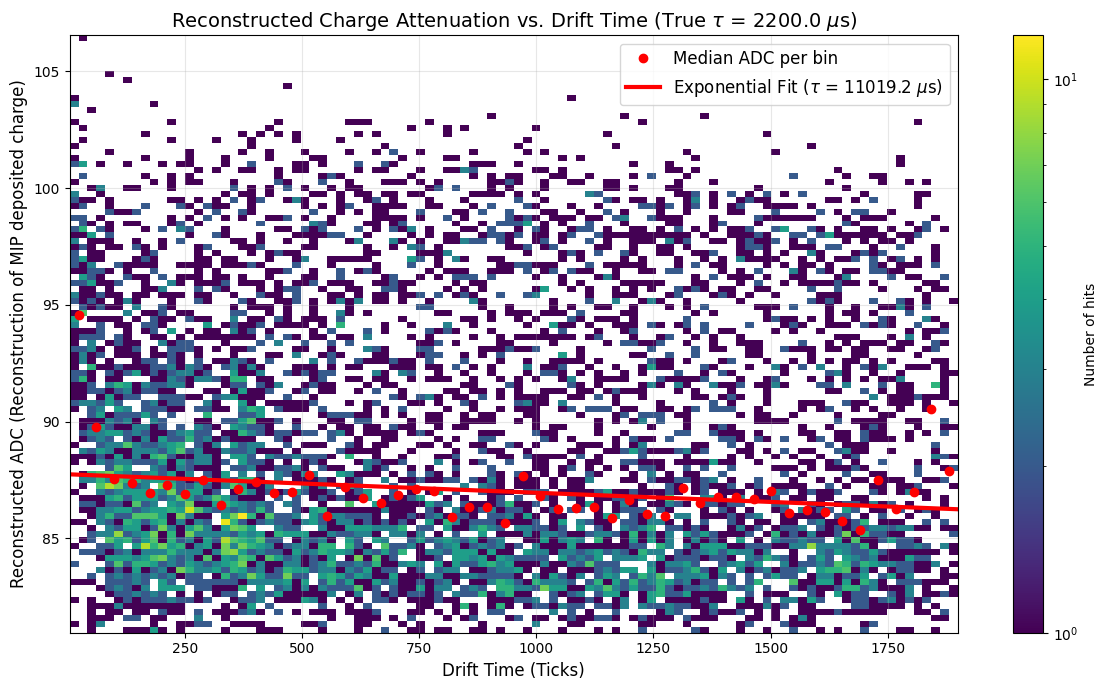

In [7]:
# --- Visualization ---
plt.figure(figsize=(12, 7))

# 2D Histogram of all hits
plt.hist2d(ticks, adcs, bins=[100, 100], cmap='viridis', cmin=1, norm=plt.matplotlib.colors.LogNorm())
plt.colorbar(label='Number of hits')

# Overlay the profile (median ADCs)
plt.plot(valid_centers, median_adcs, 'ro', label='Median ADC per bin', markersize=6)

# Overlay the fit
fit_t = np.linspace(min_tick, max_tick, 200)
fit_q = exp_decay(fit_t, *popt)
plt.plot(fit_t, fit_q, 'r-', lw=3, label=f'Exponential Fit ($\\tau$ = {fitted_tau:.1f} $\\mu$s)')

plt.title(f"Reconstructed Charge Attenuation vs. Drift Time (True $\\tau$ = {TRUE_LIFETIME} $\\mu$s)", fontsize=14)
plt.xlabel("Drift Time (Ticks)", fontsize=12)
plt.ylabel("Reconstructed ADC (Reconstruction of MIP deposited charge)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()